---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 1. Елементи електричного кола. Перетворення кіл, послідовне та паралельне з'єднання</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Ідеальні та реальні елементи електричного кола</li>
  <li>Перетворення в електричних колах</li>
  <li>Послідовне та паралельне з'єднання елементів</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 1 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Ідеальні та реальні елементи електричного кола](#ideal-real-elements)
* [Перетворення в електричних колах](#circuit-transformations)
* [Послідовне та паралельне з'єднання елементів](#series-parallel)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Ідеальні та реальні елементи електричного кола <a class="anchor" id="ideal-real-elements"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати відмінність між ідеальним та реальним елементом кола
> - Будувати схеми заміщення реальних резисторів, котушок індуктивності та конденсаторів
> - Будувати схеми заміщення реальних джерел напруги і струму
> - Застосовувати закон Ома для ділянки кола та повного кола

</div>

### 📖 Ідеальний елемент

**Ідеальний елемент** — це математична модель, що враховує лише один фізичний ефект (опір, індуктивність, ємність) і повністю ігнорує побічні (паразитні) явища. Ідеальних елементів у природі не існує — це зручна абстракція для розрахунків.

**Реальний елемент** завжди має паразитні параметри, вплив яких зростає з частотою. Схема заміщення — це електричне коло з ідеальних елементів, яке з певною точністю відтворює поведінку реального елемента в заданому діапазоні частот.

| Елемент | Ідеальна модель | Головний паразитний ефект |
|---------|-----------------|---------------------------|
| Резистор | $R$ — лише активний опір | Власна індуктивність виводів $L_s$, ємність між виводами $C_p$ |
| Котушка індуктивності | $L$ — лише накопичення магнітної енергії | Активний опір обмотки $r_L$ (втрати в міді), міжвиткова ємність $C_p$ |
| Конденсатор | $C$ — лише накопичення електричної енергії | Опір втрат $ESR$ (в діелектрику й обкладках), струм витоку $R_{вит}$, індуктивність виводів $ESL$ |
| Джерело напруги | $E$ — напруга не залежить від струму навантаження | Внутрішній опір $R_i$ — напруга на затискачах падає зі зростанням струму |
| Джерело струму | $J$ — струм не залежить від напруги на затискачах | Внутрішня провідність $G_i$ (кінцевий внутрішній опір) — частина струму «втрачається» всередині джерела |


Побудуємо схеми заміщення: реальне джерело напруги — ідеальна ЕРС $E$ послідовно з внутрішнім опором $R_i$; реальне джерело струму — ідеальне джерело $J$ паралельно з внутрішньою провідністю $G_i$.

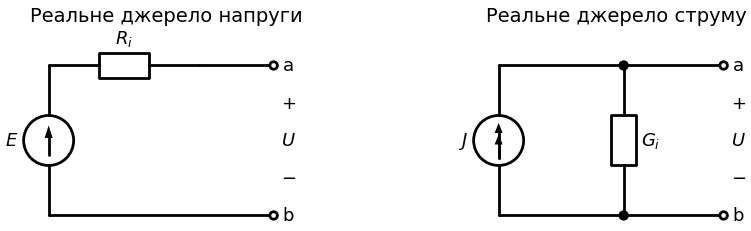

In [2]:
# Schemdraw: реальні джерела напруги і струму
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        # реальне джерело напруги: E послідовно з R_i
        E = d.add(EMF().up().label('$E$'))
        d.add(elm.Resistor().right().label('$R_i$'))
        d.add(elm.Line().right(1.5))
        a = d.add(elm.Dot(open=True).label('a', loc='right'))
        d.add(elm.Line().at(E.start).right(4.5))
        b = d.add(elm.Dot(open=True).label('b', loc='right'))
        d.add(elm.Gap().at(a.center).to(b.center).label(('+', '$U$', '−'), loc='bottom', ofst=0.3))
        d.add(elm.Label().at((2.25, 4.1)).label('Реальне джерело напруги', fontsize=14))

        # реальне джерело струму: J паралельно з G_i
        J = d.add(CurrentSource().up().at((9, 0)).label('$J$'))
        d.add(elm.Line().right(2.5))
        d.add(elm.Dot())
        d.push()
        d.add(elm.Resistor().down().label('$G_i$', loc='bottom'))
        d.add(elm.Dot())
        d.pop()
        d.add(elm.Line().right(2))
        a2 = d.add(elm.Dot(open=True).label('a', loc='right'))
        d.add(elm.Line().at(J.start).right(4.5))
        b2 = d.add(elm.Dot(open=True).label('b', loc='right'))
        d.add(elm.Gap().at(a2.center).to(b2.center).label(('+', '$U$', '−'), loc='bottom', ofst=0.3))
        d.add(elm.Label().at((11.25, 4.1)).label('Реальне джерело струму', fontsize=14))
else:
    print('Встановіть schemdraw: pip install schemdraw')

### Схеми заміщення реальних пасивних елементів

**Реальний резистор** (з урахуванням виводів, суттєво лише на високих частотах):

$$Z_R \approx R + j\omega L_s \quad (\|\, C_p \text{ паралельно всій ділянці})$$

**Реальна котушка індуктивності** — послідовно з ідеальною індуктивністю $L$ вмикають опір втрат обмотки $r_L$, а паралельно всій цій ділянці — міжвиткову ємність $C_p$:

$$Z_L(\omega) = \left(r_L + j\omega L\right) \parallel \dfrac{1}{j\omega C_p}$$

На низьких частотах $C_p$ можна знехтувати: $Z_L \approx r_L + j\omega L$. Добротність реальної котушки $Q_L = \omega L / r_L$.

**Реальний конденсатор** — послідовно з ідеальною ємністю $C$ вмикають еквівалентний послідовний опір $ESR$ (втрати в діелектрику й обкладках), а паралельно $C$ — опір витоку $R_{вит}$ (струм саморозряду):

$$Z_C(\omega) = R_{вит} \parallel \left(ESR + \dfrac{1}{j\omega C}\right)$$

Тангенс кута втрат конденсатора: $\tan\delta = \omega \cdot ESR \cdot C$.


---
### ⚡ Практичне застосування: Ідеальні й реальні елементи

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Ситуація | Чому важливо враховувати реальність елемента |
|----------|-----------------------------------------------|
| **Електролітичний конденсатор у блоці живлення** | Великий $ESR$ обмежує здатність фільтрувати високочастотні пульсації — паралельно ставлять керамічний конденсатор з малим $ESR$ |
| **Котушка індуктивності на високих частотах** | Міжвиткова ємність $C_p$ утворює власний резонанс котушки (SRF), вище якого котушка поводиться як конденсатор |
| **Батарея живлення** | Внутрішній опір $R_i$ визначає максимальний струм короткого замикання та «просідання» напруги під навантаженням |
| **Трасування на платі (доріжки)** | На високих частотах доріжка — не ідеальний провідник, а лінія з розподіленими $L$, $C$, $R$ (див. «Довга лінія», Частина 2) |

</div>

---
### ✅ Питання для самоперевірки: Ідеальні та реальні елементи

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому ідеальних елементів не існує в природі?</summary>

> **Відповідь:** Будь-який фізичний об'єкт одночасно має і опір (втрати в матеріалі), і здатність накопичувати енергію в електричному чи магнітному полі, і паразитні реактивності від геометрії (виводи, обкладки, витки). Ідеальний елемент — модель, що ізолює лише один ефект.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Як зміниться схема заміщення реального конденсатора зі зростанням частоти?</summary>

> **Відповідь:** На низьких частотах домінує опір витоку $R_{вит}$ (паралельно $C$). На високих частотах $R_{вит}$ практично не впливає (його опір набагато більший за $1/\omega C$), натомість починають впливати $ESR$ і індуктивність виводів $ESL$, послідовні з $C$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чим відрізняється поведінка реального джерела напруги від ідеального під навантаженням?</summary>

> **Відповідь:** Ідеальне джерело напруги підтримує $E=\text{const}$ незалежно від струму. Реальне джерело має внутрішній опір $R_i$, тому напруга на затискачах $U = E - I R_i$ падає зі зростанням струму навантаження.

</details>

---
### 📝 Задачі для самостійного розв'язання: Ідеальні та реальні елементи


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Реальне джерело напруги має ЕРС $E = 12$ В і внутрішній опір $R_i = 0{,}5$ Ом. До нього підключено навантаження $R_н = 5{,}5$ Ом. Знайдіть струм, напругу на затискачах джерела та ККД.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I = \dfrac{E}{R_i + R_н} = \dfrac{12}{6} = 2$ А; $U = E - IR_i = 12 - 1 = 11$ В; $\eta = \dfrac{U}{E} = \dfrac{11}{12} \approx 91{,}7\,\%$.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Керамічний конденсатор $C = 100$ нФ має паразитну індуктивність виводів $ESL = 5$ нГн. Визначте частоту власного (послідовного) резонансу. Як поводиться цей «конденсатор» вище цієї частоти?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $f_0 = \dfrac{1}{2\pi\sqrt{ESL\cdot C}} = \dfrac{1}{2\pi\sqrt{5\cdot10^{-9}\cdot 10^{-7}}} \approx 7{,}1$ МГц. Вище $f_0$ переважає $ESL$ — елемент має **індуктивний** характер, тому для блокування на вищих частотах ставлять паралельно конденсатори меншої ємності.

</details>

---

## Перетворення в електричних колах <a class="anchor" id="circuit-transformations"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Переходити від опору до провідності і навпаки
> - Виконувати взаємне перетворення джерела напруги в джерело струму
> - Застосовувати ці перетворення для спрощення розрахунку кіл

</div>

### Опір ↔ провідність

Провідність — величина, обернена до опору: $G = 1/R$ (Сименс, См). Перехід до провідності зручний, коли елементи з'єднані **паралельно** — тоді провідності просто додаються (за аналогією з опорами при послідовному з'єднанні):

$$R \;\xrightarrow{\;G=1/R\;}\; G, \qquad G \;\xrightarrow{\;R=1/G\;}\; R$$

Закон Ома в двох еквівалентних формах: $U = I R \;\Longleftrightarrow\; I = U G$.

### Джерело напруги ↔ джерело струму

Реальне джерело напруги ($E$, $R_i$ послідовно) та реальне джерело струму ($J$, $G_i$ паралельно) **еквівалентні**, якщо на будь-якому зовнішньому навантаженні вони дають однакові струм і напругу на затискачах:

$$J = \dfrac{E}{R_i}, \qquad G_i = \dfrac{1}{R_i} \qquad\Longleftrightarrow\qquad E = \dfrac{J}{G_i} = J R_i, \qquad R_i = \dfrac{1}{G_i}$$

> Перетворення справедливе лише «ззовні», з погляду затискачів кола — внутрішні процеси (розсіювання потужності на $R_i$) при цьому не зберігаються.


**Числовий приклад.** Перевіримо в SymPy еквівалентність джерел: розрахуємо струм і напругу на навантаженні $R_n$ для джерела напруги ($E$, $R_i$) і для еквівалентного джерела струму ($J = E/R_i$, $G_i = 1/R_i$). Результати мають збігатися.

In [3]:
# Числовий приклад: перетворення джерела напруги в джерело струму
E_s, Ri_s, Rn_s = smp.symbols('E R_i R_n', positive=True)

J_expr = E_s / Ri_s
Gi_expr = 1 / Ri_s

# Перевірка еквівалентності: струм і напруга на навантаженні Rn мають співпадати
I_from_V = E_s / (Ri_s + Rn_s)                     # з еквівалентної схеми "джерело напруги"
U_from_V = I_from_V * Rn_s

I_from_I = J_expr * (1/Ri_s) / (1/Ri_s + 1/Rn_s)   # струм у навантаженні зі схеми "джерело струму" (дільник струму)
U_from_I = I_from_I * Rn_s

print('Джерело напруги:  I_Rn =', smp.simplify(I_from_V), ' U_Rn =', smp.simplify(U_from_V))
print('Джерело струму:   I_Rn =', smp.simplify(I_from_I), ' U_Rn =', smp.simplify(U_from_I))
print('Різниця (має бути 0):', smp.simplify(I_from_V - I_from_I))

# Підстановка чисел: E=60 В, Ri=5 Ом, Rn=15 Ом
num = {E_s: 60, Ri_s: 5, Rn_s: 15}
print()
print('E=60 В, Ri=5 Ом  ->  J =', float(J_expr.subs(num)), 'А,  Gi =', float(Gi_expr.subs(num)), 'См')
print('Струм у навантаженні Rn=15 Ом:', float(I_from_V.subs(num)), 'А')


Джерело напруги:  I_Rn = E/(R_i + R_n)  U_Rn = E*R_n/(R_i + R_n)
Джерело струму:   I_Rn = E*R_n/(R_i*(R_i + R_n))  U_Rn = E*R_n**2/(R_i*(R_i + R_n))
Різниця (має бути 0): E*(R_i - R_n)/(R_i*(R_i + R_n))

E=60 В, Ri=5 Ом  ->  J = 12.0 А,  Gi = 0.2 См
Струм у навантаженні Rn=15 Ом: 3.0 А


---
### ⚡ Практичне застосування: Перетворення джерел

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Джерело напруги ↔ джерело струму** використовують для спрощення аналізу мішаних кіл: ділянку з паралельно ввімкненими джерелами струму зручно об'єднати в одне еквівалентне джерело простим додаванням струмів, після чого за потреби перевести результат назад у джерело напруги.

- **Модель транзистора на високій частоті** — вихідне коло часто зручніше представляти джерелом струму, кероване вхідною напругою (крутизна $g_m$), а не джерелом ЕРС.
- **Метод еквівалентного генератора** (див. розділ нижче) — теорема Тевенена (джерело напруги $E_{ек}, R_{ек}$) і теорема Нортона (джерело струму $J_{ек}, G_{ек}$) — це те саме перетворення, застосоване до всього активного двополюсника.

</div>

---
### ✅ Питання для самоперевірки: Перетворення в колах

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> У яких випадках зручніше використовувати провідність замість опору?</summary>

> **Відповідь:** Коли елементи з'єднані паралельно — провідності при паралельному з'єднанні додаються так само просто, як опори при послідовному ($G_{екв} = \sum G_k$), що спрощує запис рівнянь (наприклад, у методі вузлових потенціалів).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Реальне джерело напруги має $E=100$ В, $R_i=10$ Ом. Яке еквівалентне джерело струму?</summary>

> **Відповідь:** $J = E/R_i = 10$ А, $G_i = 1/R_i = 0{,}1$ См (тобто $R_i=10$ Ом паралельно джерелу струму).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чи зберігається потужність, що розсіюється на $R_i$, при переході від однієї еквівалентної схеми до іншої?</summary>

> **Відповідь:** Ні. Еквівалентність гарантується лише для зовнішнього кола (струм і напруга на затискачах навантаження однакові); внутрішній розподіл потужності в джерелі при цьому різний.

</details>

---
### 📝 Задачі для самостійного розв'язання: Перетворення в колах


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Джерело напруги $E = 24$ В, $R_i = 4$ Ом замініть еквівалентним джерелом струму. Перевірте еквівалентність, розрахувавши струм навантаження $R_н = 8$ Ом обома способами.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $J = E/R_i = 6$ А, внутрішній опір $R_i = 4$ Ом (паралельно). Через джерело напруги: $I_н = 24/(4+8) = 2$ А. Через джерело струму (дільник струму): $I_н = J\dfrac{R_i}{R_i + R_н} = 6\cdot\dfrac{4}{12} = 2$ А ✔.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Два реальні джерела з'єднані паралельно: $E_1 = 10$ В, $R_1 = 2$ Ом та $E_2 = 6$ В, $R_2 = 3$ Ом. Знайдіть параметри одного еквівалентного джерела напруги.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Переходимо до джерел струму: $J = 10/2 + 6/3 = 7$ А, $R_{ek} = R_1\|R_2 = 1{,}2$ Ом. Назад до джерела напруги: $E_{ek} = J R_{ek} = 8{,}4$ В.

</details>

---

## Послідовне та паралельне з'єднання елементів <a class="anchor" id="series-parallel"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Обчислювати еквівалентний опір для послідовного і паралельного з'єднання
> - Застосовувати формули дільника напруги та дільника струму
> - Розраховувати змішане (послідовно-паралельне) з'єднання резисторів

</div>

### Послідовне з'єднання

Через усі елементи протікає **однаковий струм**, напруги — додаються:

$$R_{екв} = R_1 + R_2 + \dots + R_n, \qquad U_k = I \cdot R_k = U \cdot \dfrac{R_k}{R_{екв}} \;\; \text{(дільник напруги)}$$

### Паралельне з'єднання

До всіх елементів прикладена **однакова напруга**, струми — додаються (провідності додаються):

$$\dfrac{1}{R_{екв}} = \dfrac{1}{R_1} + \dfrac{1}{R_2} + \dots + \dfrac{1}{R_n}, \qquad G_{екв} = \sum_k G_k$$

Для двох резисторів: $R_{екв} = \dfrac{R_1 R_2}{R_1+R_2}$. Дільник струму: $I_1 = I \cdot \dfrac{R_2}{R_1+R_2}$ (струм тим більший, чим менший опір цієї гілки).


Схема прикладу: резистор $R_1$ увімкнено послідовно з паралельно з'єднаними $R_2$ і $R_3$.

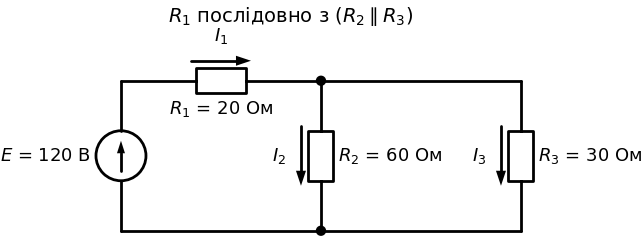

In [4]:
# Schemdraw: приклад змішаного з'єднання: R1 послідовно з (R2 || R3)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        E = d.add(EMF().up().label('$E$ = 120 В'))
        R1 = d.add(elm.Resistor().right(4).label('$R_1$ = 20 Ом', loc='bottom'))
        d.add(elm.CurrentLabel(top=True, length=1.2).at(R1).label('$I_1$'))
        top = d.add(elm.Dot())
        R2 = d.add(elm.Resistor().down().label('$R_2$ = 60 Ом', loc='bottom'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(R2).label('$I_2$'))
        d.add(elm.Dot())
        d.add(elm.Line().at(top.center).right(4))
        R3 = d.add(elm.Resistor().down().label('$R_3$ = 30 Ом', loc='bottom'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(R3).label('$I_3$'))
        d.add(elm.Line().left().tox(E.start))
        d.add(elm.Label().at((3.5, 4.4)).label('$R_1$ послідовно з ($R_2 \\parallel R_3$)', fontsize=14))
else:
    print('Встановіть schemdraw: pip install schemdraw')

Змінюйте ЕРС і опори повзунками: програма обчислює еквівалентний опір $R_{екв} = R_1 + R_2 \parallel R_3$, струми гілок і перевіряє перший закон Кірхгофа $I_1 = I_2 + I_3$.

In [5]:
# Інтерактивний розрахунок змішаного з'єднання
def series_parallel_interactive(E=120, R1=20, R2=60, R3=30):
    R23 = R2*R3/(R2+R3)
    Req = R1 + R23
    I1 = E / Req
    U23 = I1 * R23
    I2 = U23 / R2
    I3 = U23 / R3

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    bars = ax1.bar(['I1 (заг.)', 'I2', 'I3'], [I1, I2, I3],
                    color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='k')
    for bar, val in zip(bars, [I1, I2, I3]):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02*I1,
                  f'{val:.3f} A', ha='center', va='bottom')
    ax1.set_title('Струми в гілках'); ax1.set_ylabel('Струм, А')

    ax2.bar(['R_екв(23)', 'R_екв(заг.)'], [R23, Req], color=['#9C27B0', '#607D8B'], edgecolor='k')
    ax2.set_title('Еквівалентні опори'); ax2.set_ylabel('Опір, Ом')

    plt.tight_layout(); plt.show()
    print(f'R23 = {R23:.3f} Ом | Rекв = {Req:.3f} Ом')
    print(f'I1 = {I1:.4f} А | U23 = {U23:.3f} В | I2 = {I2:.4f} А | I3 = {I3:.4f} А')
    print(f'Перевірка KCL: I2+I3 = {I2+I3:.4f} А (має дорівнювати I1)')

interact(series_parallel_interactive,
         E=widgets.FloatSlider(min=10, max=220, step=5, value=120, description='E (В)'),
         R1=widgets.FloatSlider(min=1, max=100, step=1, value=20, description='R1 (Ом)'),
         R2=widgets.FloatSlider(min=1, max=200, step=1, value=60, description='R2 (Ом)'),
         R3=widgets.FloatSlider(min=1, max=200, step=1, value=30, description='R3 (Ом)'));


interactive(children=(FloatSlider(value=120.0, description='E (В)', max=220.0, min=10.0, step=5.0), FloatSlide…

---
### ⚡ Практичне застосування: Послідовне та паралельне з'єднання

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Пристрій | Тип з'єднання |
|----------|---------------|
| **Потенціометр (регулятор гучності)** | Дільник напруги на змінному резисторі |
| **R-2R драбинка (ЦАП)** | Комбіноване послідовно-паралельне з'єднання резисторів |
| **Шунт амперметра** | Малий опір паралельно приладу — дільник струму |
| **Додатковий опір вольтметра** | Великий опір послідовно з приладом — дільник напруги |
| **Гірлянда світлодіодних ламп (старого типу)** | Послідовне з'єднання — обрив одного елемента розриває все коло |

</div>

---
### ✅ Питання для самоперевірки: Послідовне та паралельне з'єднання

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому еквівалентний опір паралельного з'єднання завжди менший за найменший з опорів?</summary>

> **Відповідь:** Кожна додаткова паралельна гілка додає новий шлях для струму (додає провідність), тому загальна провідність зростає, а отже еквівалентний опір $R_{екв}=1/G_{екв}$ спадає і завжди менший за опір будь-якої окремої гілки.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Три резистори по 30 Ом з'єднані паралельно. Чому дорівнює Rекв?</summary>

> **Відповідь:** $R_{екв} = 30/3 = 10$ Ом (для $n$ однакових паралельних резисторів $R_{екв}=R/n$).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Як формула дільника напруги пов'язана з методом еквівалентного генератора?</summary>

> **Відповідь:** Дільник напруги — окремий випадок: якщо розглядати $R_2$ як навантаження, а решту кола (E, R1) — як еквівалентний генератор, то $U_{R_2}=E\cdot R_2/(R_1+R_2)$ — це і є напруга холостого ходу, помножена на коефіцієнт передачі дільника.

</details>

---
### 📝 Задачі для самостійного розв'язання: Послідовне та паралельне з'єднання


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Резистор $R_1 = 10$ Ом увімкнено послідовно з паралельно з'єднаними $R_2 = 20$ Ом і $R_3 = 30$ Ом. Напруга живлення $E = 44$ В. Знайдіть усі струми.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $R_{екв} = 10 + \dfrac{20\cdot30}{50} = 22$ Ом; $I_1 = 2$ А; $U_{23} = 2\cdot 12 = 24$ В; $I_2 = 1{,}2$ А; $I_3 = 0{,}8$ А. Перевірка за І законом Кірхгофа: $1{,}2 + 0{,}8 = 2$ ✔.

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Дільник напруги $R_1 = 3$ кОм, $R_2 = 1$ кОм живиться від 12 В. Яка вихідна напруга на $R_2$ без навантаження і з навантаженням $R_н = 1$ кОм?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> Без навантаження: $U_2 = 12\cdot\dfrac{1}{4} = 3$ В. З навантаженням: $R_2\|R_н = 500$ Ом, $U_2 = 12\cdot\dfrac{0{,}5}{3{,}5} \approx 1{,}71$ В — навантаження суттєво «просаджує» дільник, тому $R_н$ має бути значно більшим за $R_2$.

</details>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">[Тема 2. Закони Кірхгофа](Тема_02_Закони_Кірхгофа.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
